# Hell_Rob_Waves
this script serves to show the method used in Garny and Reichert (2026) in preparation for GJR Letters to derive gravity wave momentum fluxes as function of directional phase speed and altitude. Since global UA-ICON simulations are available on a temporal resolution of 6h, the key idea to derive phase speeds is to use the dispersion relation to get the wave's frequency. Our simple approach is to compute the 2-D FFT in a defined (lon, lat) box and derive the vertical wavenumber via the phase shift between two adjacent layers. The method is applied to UA-ICON simulations. More details should be mentioned.

In [1]:
import sys
sys.path.append('../robFFT')
from robFFT import robfft
from robFFT import watson

import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
import cartopy.crs as ccrs

/home/r/Robert.Reichert/.conda/envs/hell_waves/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


In [2]:
path = '../data/ICON_DOM01_HL_20150827T120000Z.nc'
ds = xr.open_dataset(path)

In [3]:
pert = robfft.remove_background(ds,variables=['w','temp','u','v'],dim_lat='lat',dim_lon='lon',wl_cutoff=2000)
#da_u = ds['u'].sel(alt=100_000,method='nearest')
#u_12h_tide = watson.extract_semidiurnal_wave2(da_u, time_in_hours=da_u.time*24)
#da_v = ds['v'].sel(alt=100_000,method='nearest')
#v_12h_tide = watson.extract_semidiurnal_wave2(da_v, time_in_hours=da_v.time*24)

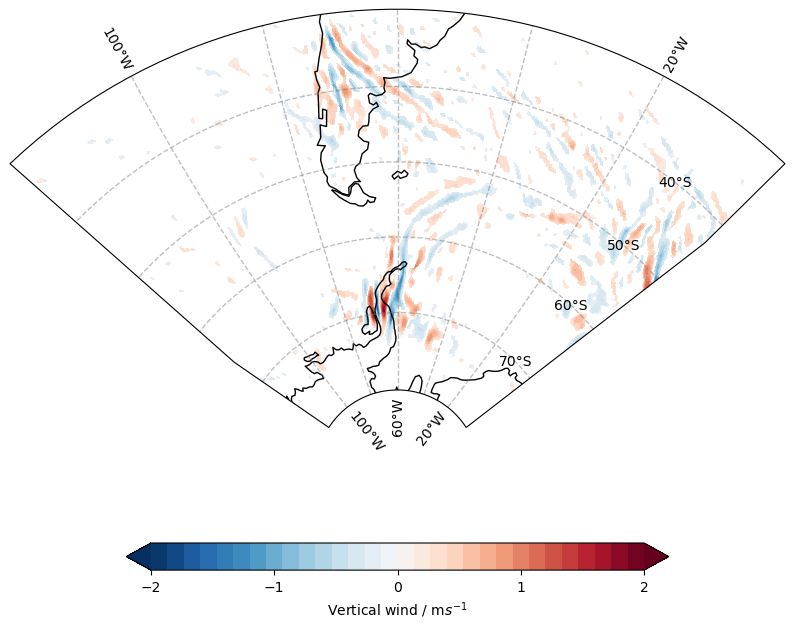

In [25]:
time_index = 1
da = pert['w'].isel(time=time_index).sel(alt=40_000,method='nearest')

# Define the geografic region that is under investigation.
lonW = -120
lonE = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev   = np.linspace(-2,2,31)
clon    = (lonW+lonE)/2
clat    = (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path    = watson.nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

fig=plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels  = True  # Hide labels on the right side
gridlines.left_labels   = True  # Hide labels on the right side
gridlines.top_labels    = False # Hide labels on the top
gridlines.bottom_labels = True  # Hide labels on the top

masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [4]:
# Define Box of interest
ds_box  = pert.sel(lon=slice(-75,-55),lat=slice(-75,-60)).isel(time=1)
cart_ds = robfft.lonlat_to_cartesian_grid(ds_box, lon="lon", lat="lat")
rob_res = robfft.compute_vertical_wavenumber_and_intrinsic_frequency(cart_ds,'w',dim_x='x',dim_y='y',dim_z='alt',tapering=True,lat_mean=-67.5)
MF_res  = robfft.compute_momentum_flux(cart_ds,dim_x='x',dim_y='y',dim_z='alt', tapering=True)
EF_res  = robfft.compute_energy_flux(cart_ds,dim_x='x',dim_y='y',dim_z='alt', tapering=True)

Text(0, 0.5, '$k_y$ / $km^{-1}$')

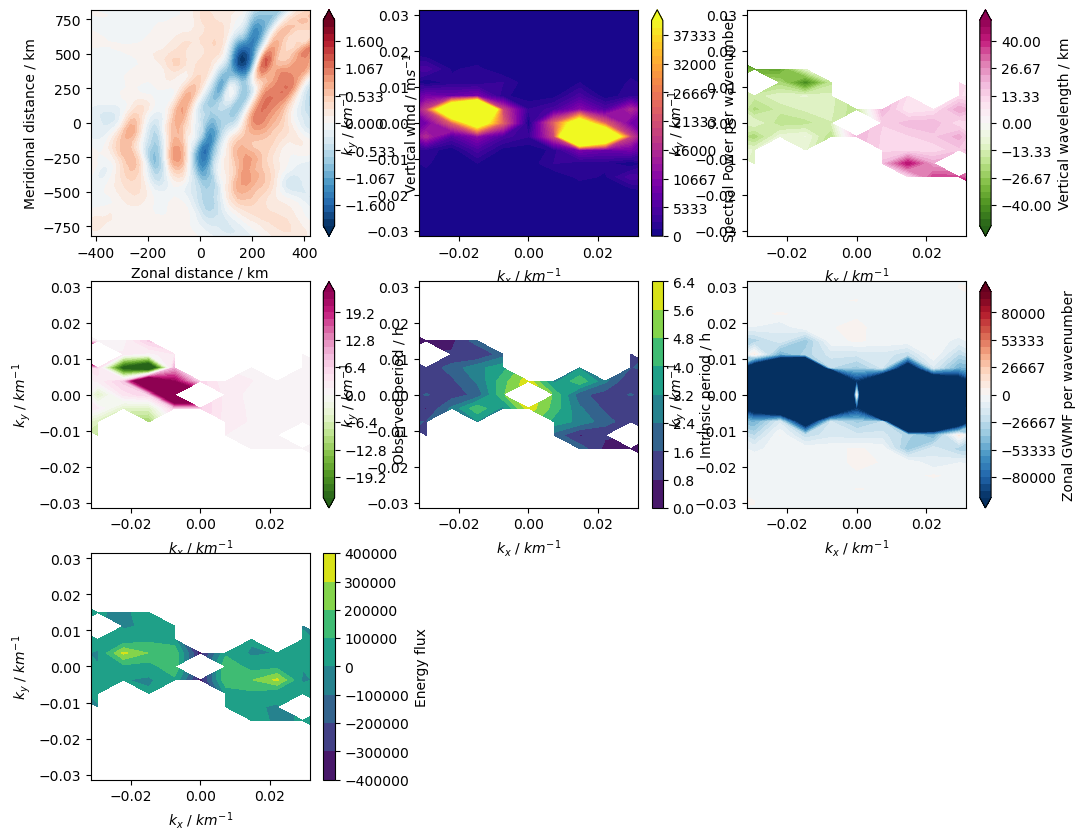

In [8]:
z0 = 40_000
power_threshold = 1_000

rows, colm = watson.define_grid(7)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(rows,colm,1)
plot_w = plt.contourf(cart_ds.x*1e-3,cart_ds.y*1e-3,cart_ds['w'].sel(alt=z0,method='nearest'),levels=np.linspace(-2,2,31),cmap='RdBu_r',extend='both')
cbar=fig.colorbar(plot_w,label='Vertical wind / m$s^{-1}$')
ax.set_xlabel('Zonal distance / km')
ax.set_ylabel('Meridional distance / km')

ax = fig.add_subplot(rows,colm,2)
power = rob_res['spectral_power'].sel(alt=z0, method='nearest').T
plot_spectrum = plt.contourf(rob_res.kx*1e3,rob_res.ky*1e3,power,levels=np.linspace(0,40_000,31),cmap='plasma',extend='max')
cbar = fig.colorbar(plot_spectrum,label='Spectral Power per wavenumber')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,3)
mfield = 2*np.pi/rob_res['m'].sel(alt=z0, method='nearest').T*1e-3
m_masked = np.ma.masked_where(power <= power_threshold, mfield)
plot_m = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, m_masked, levels=np.linspace(-50,50,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_m, ax=ax, label='Vertical wavelength / km')
ax.set_xlim([-2*np.pi/200, 2*np.pi/200])
ax.set_ylim([-2*np.pi/200, 2*np.pi/200])
ax.set_xlabel(r'$k_x$ / $km^{-1}$')
ax.set_ylabel(r'$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,4)
omfield = 2*np.pi/rob_res['omega_shifted'].sel(alt=z0, method='nearest').T/3_600
om_masked = np.ma.masked_where(power <= power_threshold, omfield)
plot_om = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, om_masked, levels=np.linspace(-24,24,31),extend='both',cmap='PiYG_r')
cbar = fig.colorbar(plot_om, ax=ax, label='Observed period / h')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,5)
omfield = 2*np.pi/rob_res['omega'].sel(alt=z0, method='nearest').T/3_600
om_masked = np.ma.masked_where(power <= power_threshold, omfield)
plot_om = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, om_masked)#, levels=np.linspace(0,350,31),extend='max')
cbar = fig.colorbar(plot_om, ax=ax, label='Intrinsic period / h')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,6)
plot_MF = ax.contourf(MF_res.kx*1e3, MF_res.ky*1e3, MF_res['uw'].sel(alt=z0,method='nearest').T, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_MF, ax=ax, label='Zonal GWMF per wavenumber')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,7)
EF_field = EF_res['pw'].sel(alt=z0, method='nearest').T
EF_masked = np.ma.masked_where(power <= power_threshold, EF_field)
plot_EF = ax.contourf(EF_res.kx*1e3, EF_res.ky*1e3, EF_masked)#, levels=np.linspace(0,350,31),extend='max')
#plot_EF = ax.contourf(EF_res.kx*1e3, EF_res.ky*1e3, EF_res['pw'].sel(alt=z0,method='nearest').T)#, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_EF, ax=ax, label='Energy flux')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

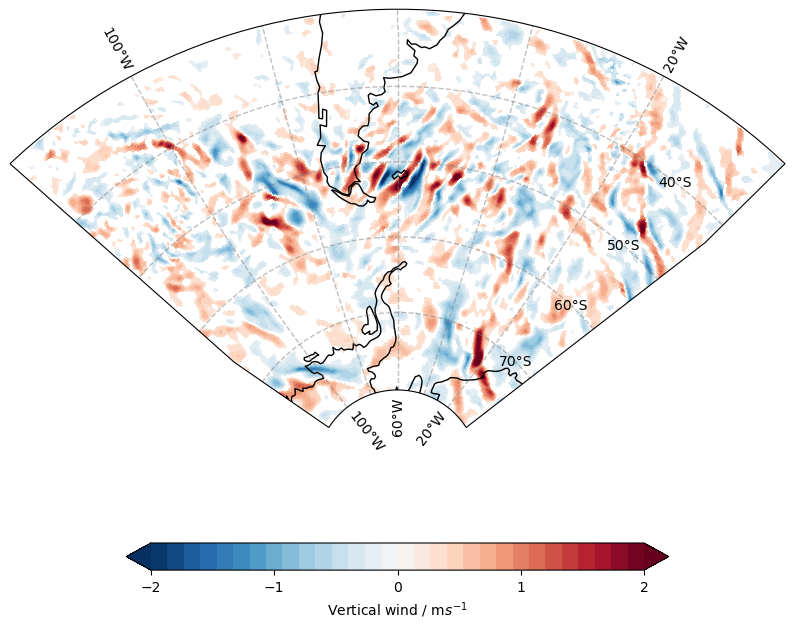

In [9]:
time_index = 1
da = pert['w'].isel(time=time_index).sel(alt=100_000,method='nearest')

# Define the geografic region that is under investigation.
lonW = -120
lonE = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev   = np.linspace(-2,2,31)
clon    = (lonW+lonE)/2
clat    = (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path    = watson.nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

fig=plt.figure(figsize=(10,10))
ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels  = True  # Hide labels on the right side
gridlines.left_labels   = True  # Hide labels on the right side
gridlines.top_labels    = False # Hide labels on the top
gridlines.bottom_labels = True  # Hide labels on the top

masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")

In [10]:
# Define Box of interest
ds_box  = pert.sel(lon=slice(-80,-40),lat=slice(-60,-40)).isel(time=1)
cart_ds = robfft.lonlat_to_cartesian_grid(ds_box, lon="lon", lat="lat")
rob_res = robfft.compute_vertical_wavenumber_and_intrinsic_frequency(cart_ds,'w',dim_x='x',dim_y='y',dim_z='alt',tapering=True,lat_mean=-50)
MF_res  = robfft.compute_momentum_flux(cart_ds,dim_x='x',dim_y='y',dim_z='alt', tapering=True)
EF_res  = robfft.compute_energy_flux(cart_ds,dim_x='x',dim_y='y',dim_z='alt', tapering=True)

Text(0, 0.5, '$k_y$ / $km^{-1}$')

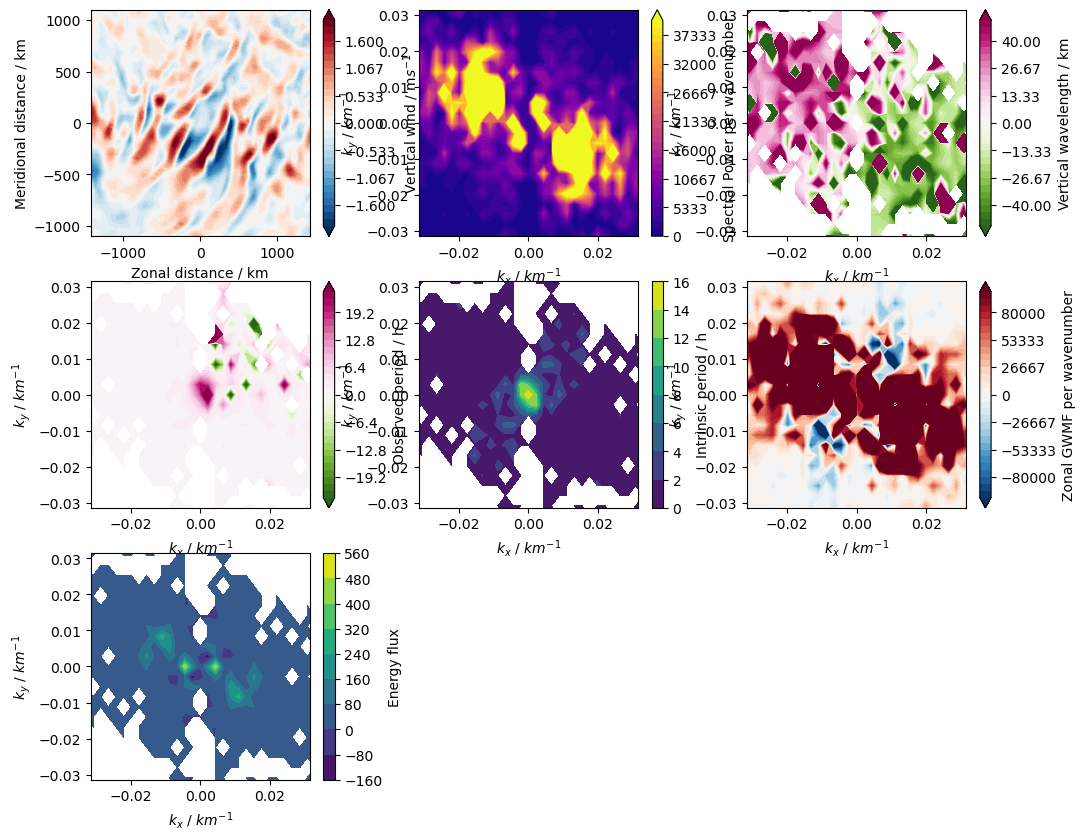

In [11]:
z0 = 100_000
power_threshold = 1_000

rows, colm = watson.define_grid(7)

fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot(rows,colm,1)
plot_w = plt.contourf(cart_ds.x*1e-3,cart_ds.y*1e-3,cart_ds['w'].sel(alt=z0,method='nearest'),levels=np.linspace(-2,2,31),cmap='RdBu_r',extend='both')
cbar=fig.colorbar(plot_w,label='Vertical wind / m$s^{-1}$')
ax.set_xlabel('Zonal distance / km')
ax.set_ylabel('Meridional distance / km')

ax = fig.add_subplot(rows,colm,2)
power = rob_res['spectral_power'].sel(alt=z0, method='nearest').T
plot_spectrum = plt.contourf(rob_res.kx*1e3,rob_res.ky*1e3,power,levels=np.linspace(0,40_000,31),cmap='plasma',extend='max')
cbar = fig.colorbar(plot_spectrum,label='Spectral Power per wavenumber')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,3)
mfield = 2*np.pi/rob_res['m'].sel(alt=z0, method='nearest').T*1e-3
m_masked = np.ma.masked_where(power <= power_threshold, mfield)
plot_m = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, m_masked, levels=np.linspace(-50,50,31),cmap='PiYG_r',extend='both')
cbar = fig.colorbar(plot_m, ax=ax, label='Vertical wavelength / km')
ax.set_xlim([-2*np.pi/200, 2*np.pi/200])
ax.set_ylim([-2*np.pi/200, 2*np.pi/200])
ax.set_xlabel(r'$k_x$ / $km^{-1}$')
ax.set_ylabel(r'$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,4)
omfield = 2*np.pi/rob_res['omega_shifted'].sel(alt=z0, method='nearest').T/3_600
om_masked = np.ma.masked_where(power <= power_threshold, omfield)
plot_om = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, om_masked, levels=np.linspace(-24,24,31),extend='both',cmap='PiYG_r')
cbar = fig.colorbar(plot_om, ax=ax, label='Observed period / h')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,5)
omfield = 2*np.pi/rob_res['omega'].sel(alt=z0, method='nearest').T/3_600
om_masked = np.ma.masked_where(power <= power_threshold, omfield)
plot_om = ax.contourf(rob_res.kx*1e3, rob_res.ky*1e3, om_masked)#, levels=np.linspace(0,350,31),extend='max')
cbar = fig.colorbar(plot_om, ax=ax, label='Intrinsic period / h')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,6)
plot_MF = ax.contourf(MF_res.kx*1e3, MF_res.ky*1e3, MF_res['uw'].sel(alt=z0,method='nearest').T, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_MF, ax=ax, label='Zonal GWMF per wavenumber')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

ax = fig.add_subplot(rows,colm,7)
EF_field = EF_res['pw'].sel(alt=z0, method='nearest').T
EF_masked = np.ma.masked_where(power <= power_threshold, EF_field)
plot_EF = ax.contourf(EF_res.kx*1e3, EF_res.ky*1e3, EF_masked)#, levels=np.linspace(0,350,31),extend='max')
#plot_EF = ax.contourf(EF_res.kx*1e3, EF_res.ky*1e3, EF_res['pw'].sel(alt=z0,method='nearest').T)#, levels=np.linspace(-100_000,100_000,31),extend='both',cmap='RdBu_r')
cbar = fig.colorbar(plot_EF, ax=ax, label='Energy flux')
ax.set_xlim([-2*np.pi/200,2*np.pi/200])
ax.set_ylim([-2*np.pi/200,2*np.pi/200])
ax.set_xlabel('$k_x$ / $km^{-1}$')
ax.set_ylabel('$k_y$ / $km^{-1}$')

In [ ]:
time_index = 1
da = ds['w'].isel(time=time_index).sel(alt=100_000,method='nearest')
da_u = ds['u'].isel(time=time_index).sel(alt=100_000,method='nearest')

# Define the geografic region that is under investigation.
lonW    = -120
lonE    = 0
latS = -80
latN = -30

extent_SP=[lonW, lonE, latS, latN]

w_lev = np.linspace(-2,2,31)
u_lev = np.linspace(0,150,31)
fig=plt.figure(figsize=(10,10))
clon, clat = (lonW+lonE)/2, (latN+latS)/2
projStr = ccrs.Stereographic(central_longitude=clon, central_latitude=clat)
path = nice_boundary_path_for_maps(np.linspace(lonW,lonE,50), np.linspace(latS,latN,50))

ax = fig.add_subplot(projection=projStr)

ax.set_boundary(path, transform=ccrs.PlateCarree())
ax.set_extent([lonW, lonE, latS, latN], ccrs.PlateCarree())
ax.coastlines()
gridlines = ax.gridlines(draw_labels=True, linewidth=1, color='gray', alpha=0.5, linestyle='--')
gridlines.right_labels = True  # Hide labels on the right side
gridlines.left_labels = True  # Hide labels on the right side
gridlines.top_labels = False    # Hide labels on the top
gridlines.bottom_labels = True    # Hide labels on the top

masked = np.ma.masked_inside(da.sel(lat=slice(extent_SP[2],extent_SP[3])), -0.2, 0.2)  
plot_w_high = plt.contourf(ds.lon,ds.lat.sel(lat=slice(extent_SP[2],extent_SP[3])),masked,transform=ccrs.PlateCarree(),levels=w_lev,extend='both',cmap='RdBu_r')

wind = np.sqrt((u_12h_tide['mean_fit']+u_12h_tide['tide'].isel(time=time_index))**2+(v_12h_tide['mean_fit']+v_12h_tide['tide'].isel(time=time_index))**2)
masked = np.ma.masked_inside(wind, 0, 5) 
plot_wind = plt.contourf(ds.lon,ds.lat,masked,transform=ccrs.PlateCarree(),levels=np.linspace(5,100,20),extend='both',cmap='plasma',alpha=0.2)
LON, LAT = np.meshgrid(ds.lon, ds.lat)
plt.quiver(LON[::10,::10],LAT[::10,::10],masked[::10,::10],transform=ccrs.PlateCarree())
#masked = np.ma.masked_outside(v_12h_tide['mean_fit']+v_12h_tide['tide'].isel(time=time_index), -50, -5) 
#plot_u = plt.contourf(ds.lon,ds.lat,masked,transform=ccrs.PlateCarree(),levels=np.linspace(-50,-5,5),extend='both',cmap='viridis',alpha=0.2)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
cbar = fig.colorbar(plot_w_high, orientation='horizontal',extend='both',label='Vertical wind / m$s^{-1}$',shrink=0.7,ticks=[-2,-1,0,1,2])
#plt.savefig('./figures/ICON_w_100km_20150828T06.png', dpi=120, facecolor="w", edgecolor="w", bbox_inches="tight")